In [1]:
import sys
print(sys.executable)

c:\Users\HP\Documents\my projects\object detection notebook gemini 2.5 flash\venv\Scripts\python.exe


In [2]:
import os
import json
import google.generativeai as genai
from dotenv import load_dotenv
from PIL import Image
import matplotlib.pyplot as plt
import cv2

c:\Users\HP\Documents\my projects\object detection notebook gemini 2.5 flash\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HP\AppData\Local\Temp\ipykernel_9628\1355207299.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
!pip install ipywidgets

   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ----- ---------------------------------- 20.5/139.8 kB ? eta -:--:--
   -------- ------------------------------- 30.7/139.8 kB 1.4 MB/s eta 0:00:01
   -------- ------------------------------- 30.7/139.8 kB 1.4 MB/s eta 0:00:01
   ----------- --------------------------- 41.0/139.8 kB 219.4 kB/s eta 0:00:01
   ----------- --------------------------- 41.0/139.8 kB 219.4 kB/s eta 0:00:01
   ------------------- ------------------- 71.7/139.8 kB 262.6 kB/s eta 0:00:01
   ------------------- ------------------- 71.7/139.8 kB 262.6 kB/s eta 0:00:01
   ---------------------

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\Documents\\my projects\\object detection notebook gemini 2.5 flash\\venv\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\vendors-node_modules_d3-color_src_color_js-node_modules_d3-format_src_defaultLocale_js-node_m-09b215.2643c43f22ad111f4f82.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
print("kernel restarted")

kernel restarted


In [3]:
load_dotenv()
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

In [6]:
model = genai.GenerativeModel("gemini-2.5-flash")

(np.float64(-0.5), np.float64(735.5), np.float64(489.5), np.float64(-0.5))

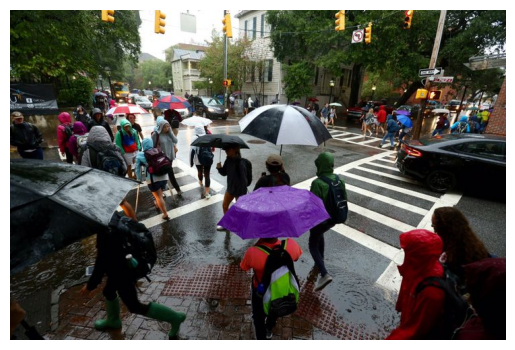

In [9]:
image_path = "sample_image.jpg"
image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')

In [19]:
prompt = """
detect all objects in this image
return only raw json 
no explainations
no markdown
no text before or after
only json
"""

In [14]:
response = model.generate_content([prompt,image])
print(response.text)

[
  {"box_2d": [0, 269, 58, 310], "label": "traffic light"},
  {"box_2d": [1, 410, 75, 436], "label": "traffic light"},
  {"box_2d": [1, 629, 68, 666], "label": "traffic light"},
  {"box_2d": [47, 706, 105, 729], "label": "traffic light"},
  {"box_2d": [104, 718, 172, 755], "label": "traffic light"},
  {"box_2d": [142, 815, 178, 868], "label": "street sign"},
  {"box_2d": [183, 819, 215, 865], "label": "street sign"},
  {"box_2d": [109, 707, 137, 735], "label": "no turn on red sign"},
  {"box_2d": [256, 248, 304, 297], "label": "vehicle"},
  {"box_2d": [237, 290, 312, 370], "label": "vehicle"},
  {"box_2d": [275, 426, 324, 477], "label": "vehicle"},
  {"box_2d": [282, 857, 340, 936], "label": "vehicle"},
  {"box_2d": [343, 762, 597, 1000], "label": "vehicle"},
  {"box_2d": [237, 290, 312, 370], "label": "car"},
  {"box_2d": [275, 426, 324, 477], "label": "car"},
  {"box_2d": [282, 857, 340, 936], "label": "car"},
  {"box_2d": [343, 762, 597, 1000], "label": "car"},
  {"box_2d": [237, 2

In [17]:
cleaned_text = response.text.strip()
data = json.loads(cleaned_text)
data

[{'box_2d': [0, 269, 58, 310], 'label': 'traffic light'},
 {'box_2d': [1, 410, 75, 436], 'label': 'traffic light'},
 {'box_2d': [1, 629, 68, 666], 'label': 'traffic light'},
 {'box_2d': [47, 706, 105, 729], 'label': 'traffic light'},
 {'box_2d': [104, 718, 172, 755], 'label': 'traffic light'},
 {'box_2d': [142, 815, 178, 868], 'label': 'street sign'},
 {'box_2d': [183, 819, 215, 865], 'label': 'street sign'},
 {'box_2d': [109, 707, 137, 735], 'label': 'no turn on red sign'},
 {'box_2d': [256, 248, 304, 297], 'label': 'vehicle'},
 {'box_2d': [237, 290, 312, 370], 'label': 'vehicle'},
 {'box_2d': [275, 426, 324, 477], 'label': 'vehicle'},
 {'box_2d': [282, 857, 340, 936], 'label': 'vehicle'},
 {'box_2d': [343, 762, 597, 1000], 'label': 'vehicle'},
 {'box_2d': [237, 290, 312, 370], 'label': 'car'},
 {'box_2d': [275, 426, 324, 477], 'label': 'car'},
 {'box_2d': [282, 857, 340, 936], 'label': 'car'},
 {'box_2d': [343, 762, 597, 1000], 'label': 'car'},
 {'box_2d': [237, 290, 312, 370], 'labe

In [20]:
print(data)

[{'box_2d': [0, 269, 58, 310], 'label': 'traffic light'}, {'box_2d': [1, 410, 75, 436], 'label': 'traffic light'}, {'box_2d': [1, 629, 68, 666], 'label': 'traffic light'}, {'box_2d': [47, 706, 105, 729], 'label': 'traffic light'}, {'box_2d': [104, 718, 172, 755], 'label': 'traffic light'}, {'box_2d': [142, 815, 178, 868], 'label': 'street sign'}, {'box_2d': [183, 819, 215, 865], 'label': 'street sign'}, {'box_2d': [109, 707, 137, 735], 'label': 'no turn on red sign'}, {'box_2d': [256, 248, 304, 297], 'label': 'vehicle'}, {'box_2d': [237, 290, 312, 370], 'label': 'vehicle'}, {'box_2d': [275, 426, 324, 477], 'label': 'vehicle'}, {'box_2d': [282, 857, 340, 936], 'label': 'vehicle'}, {'box_2d': [343, 762, 597, 1000], 'label': 'vehicle'}, {'box_2d': [237, 290, 312, 370], 'label': 'car'}, {'box_2d': [275, 426, 324, 477], 'label': 'car'}, {'box_2d': [282, 857, 340, 936], 'label': 'car'}, {'box_2d': [343, 762, 597, 1000], 'label': 'car'}, {'box_2d': [237, 290, 312, 370], 'label': 'black car'},

In [21]:
img =cv2.imread(image_path)
for obj in data:
    x1,y1,x2,y2 = obj["box_2d"]
    label = obj["label"]
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.putText(img,label,(x1,y1-10),
                cv2.FONT_HERSHEY_DUPLEX,0.5,(0,255,0),2)

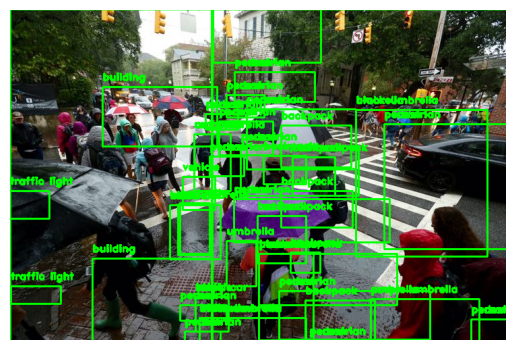

In [22]:
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [31]:
import random
label_colors = {}
for obj in data:
    label = obj["label"]
    if label not in label_colors:
        label_colors[label] = (
            random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255)
        )

In [45]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(image_path)
for obj in data:
    x1,y1,x2,y2 = obj["box_2d"]
    label = obj["label"]
    color = label_colors[label]
    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(img,label,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,color,2)

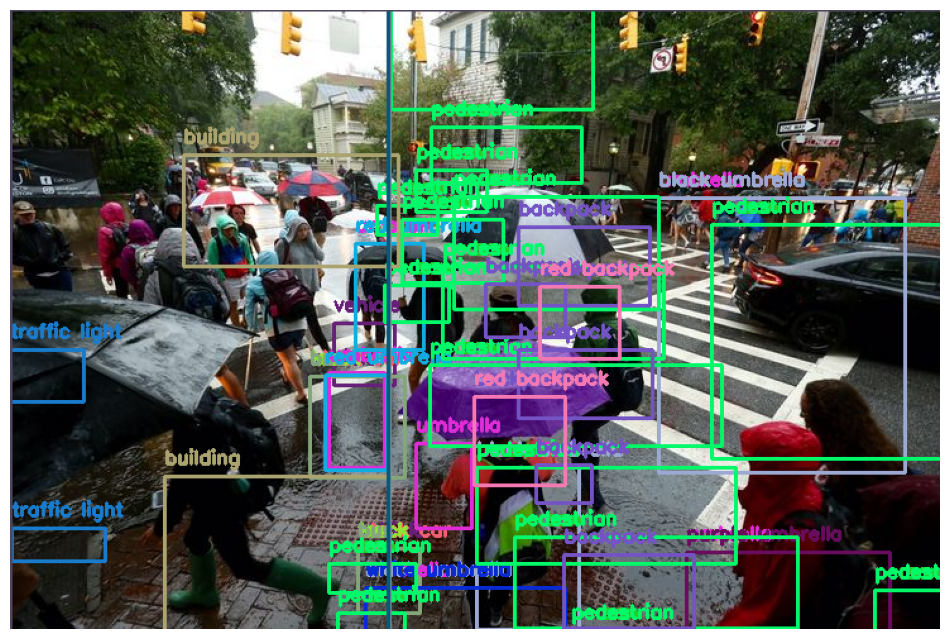

In [ ]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(image_path)
for obj in data:
    x1,y1,x2,y2 = obj["box_2d"]
    label = obj["label"]
    color = label_colors[label]
    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(img,label,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,color,2)

In [ ]:
unique_boxes ={}
for obj in data:
    box = tuple(obj["box_2d"])
    label = obj["label"]
    if box not in unique_boxes:
        unique_boxes[box] = label
        cleaned_data=[
                {"box_2d" : list(box), "label" : label}
                for box, label in unique_boxes.items()
        ] 

In [49]:
category_colors = {"vehicle": (255, 0, 0), "person": (0, 255, 0), "sign": (0, 255, 255), "accessory": (255, 0, 255), "environment": (255, 255, 0), "other": (200, 200, 200)}
def get_category(label):
    label = label.lower()
    if any(x in label for x in ["car", "truck", "bus", "vehicle", "suv"]):
        return "vehicle"
    elif any(x in label for x in ["person", "pedestrian"]):
        return "person"
    elif any(x in label for x in ["sign", "traffic light"]):
        return "sign"
    elif any(x in label for x in ["umbrella", "backpack", "boot"]):
        return "accessory"
    elif any(x in label for x in ["road", "street", "building", "sidewalk", "crosswalk"]):
        return "environment"
    else:
        return "other"

In [50]:
img = cv2.imread(image_path)
for obj in cleaned_data:
    x1,y1,x2,y2 = obj["box_2d"]
    label = obj["label"]
    category = get_category(label)
    color = category_colors[category]
    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(img,label,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,color,2)

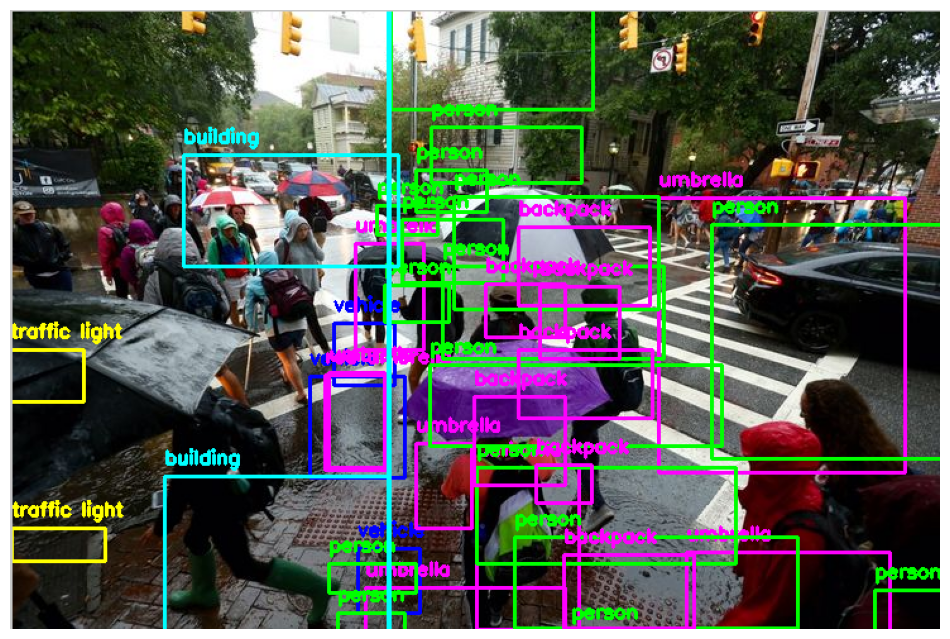

In [51]:
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [53]:
from collections import Counter
category_list = []
for obj in cleaned_data:
    category = get_category(obj["label"])
    category_list.append(category)
category_counts = Counter(category_list)
print("object count:")
for cat, count in category_counts.items():
    print(f"{cat}: {count}")

object count:
sign: 8
vehicle: 5
accessory: 24
person: 29
environment: 6
other: 1


In [54]:
y_offset = 25
for category, color in category_colors.items():
    cv2.rectangle(img, (10, y_offset-15), (30, y_offset+5), color, -1)
    cv2.putText(img, category, (40, y_offset),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    y_offset += 25

In [55]:
overlay = img.copy()
for obj in cleaned_data:
    x1,y1,x2,y2 = obj["box_2d"]
    label = obj["label"]
    category = get_category(label)
    color = category_colors[category]
    cv2.rectangle(overlay, (x1,y1), (x2,y2), color, -1)
alpha = 0.4
cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

array([[[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [ 82,  92,  85],
        ...,
        [ 90, 100,  93],
        [ 88, 100,  93],
        [ 88, 100,  92]],

       ...,

       [[200, 200, 200],
        [200, 200, 200],
        [ 80,  81,  84],
        ...,
        [ 82,  80,  81],
        [ 82,  80,  81],
        [ 82,  80,  81]],

       [[200, 200, 200],
        [200, 200, 200],
        [ 80,  81,  84],
        ...,
        [ 82,  80,  81],
        [ 82,  80,  81],
        [ 82,  80,  81]],

       [[200, 200, 200],
        [200, 200, 200],
        [ 80,  81,  84],
        ...,
        [ 82,  80,  81],
        [ 82,  80,  81],
        [ 82,  80,  81]]

In [ ]:
import numpy as np
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = box1_area + box2_area - inter_area
    return inter_area/union if union > 0 else 0

In [57]:
def nms(data, iou_threshold=0.4):
    final = []
    while data:
        chosen = data.pop(0)
        final.append(chosen)
        data = [
            obj for obj in data
            if compute_iou(chosen["box_2d"], obj["box_2d"]) < iou_threshold
        ]
    return final

In [58]:
cleaned_data = nms(cleaned_data)

In [61]:
print("Before NMS:", len(cleaned_data))
cleaned_data = nms(cleaned_data.copy(), 0.4)
print("After NMS:", len(cleaned_data))

Before NMS: 66
After NMS: 66


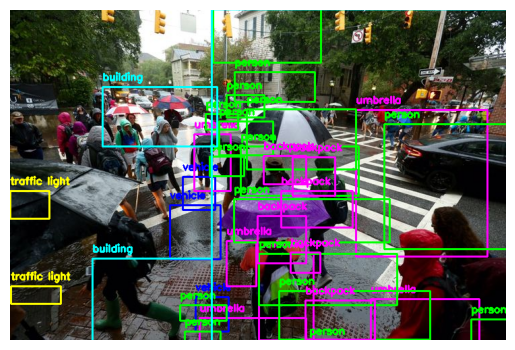

In [62]:
img = cv2.imread(image_path)
for obj in cleaned_data:
    x1, y1, x2, y2 = obj["box_2d"]
    label = obj["label"]
    category = get_category(label)
    color = category_colors[category]
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [63]:
print("Before NMS:", len(cleaned_data))
cleaned_data = nms(cleaned_data.copy())
print("After NMS:", len(cleaned_data))

Before NMS: 66
After NMS: 66
